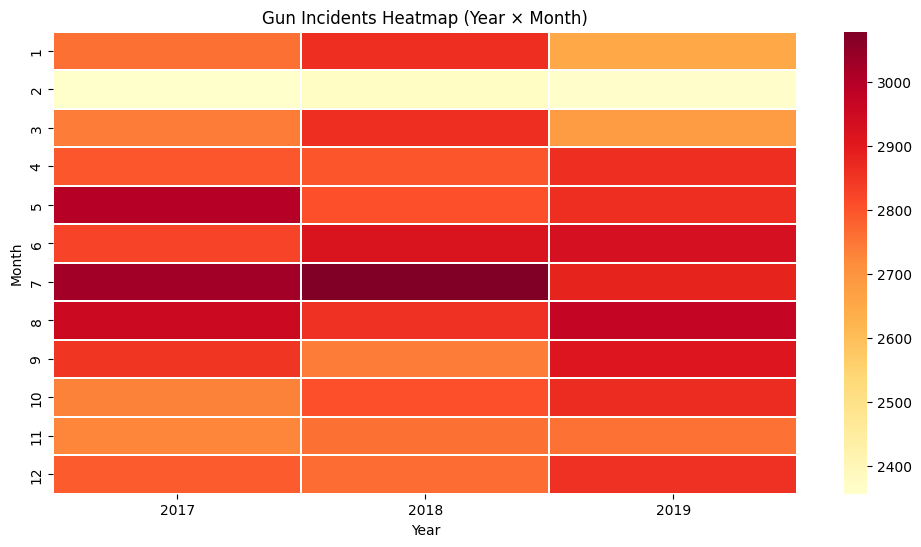

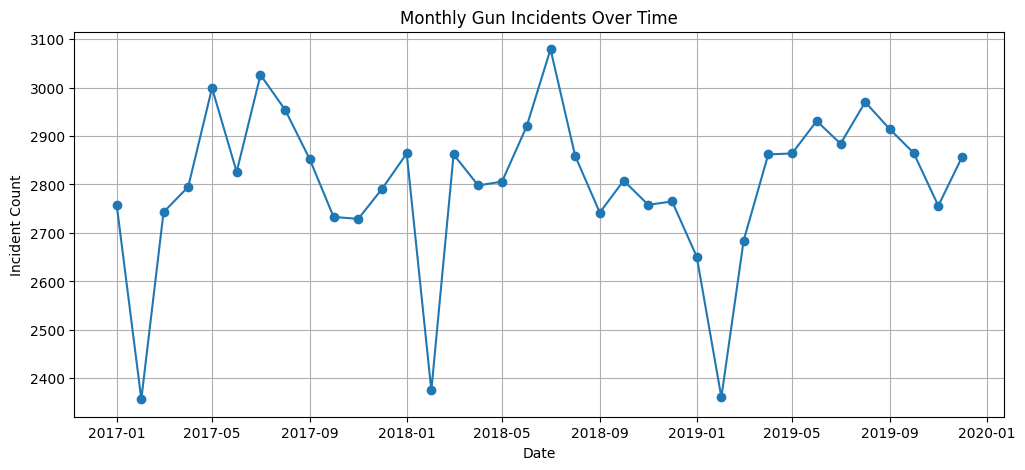

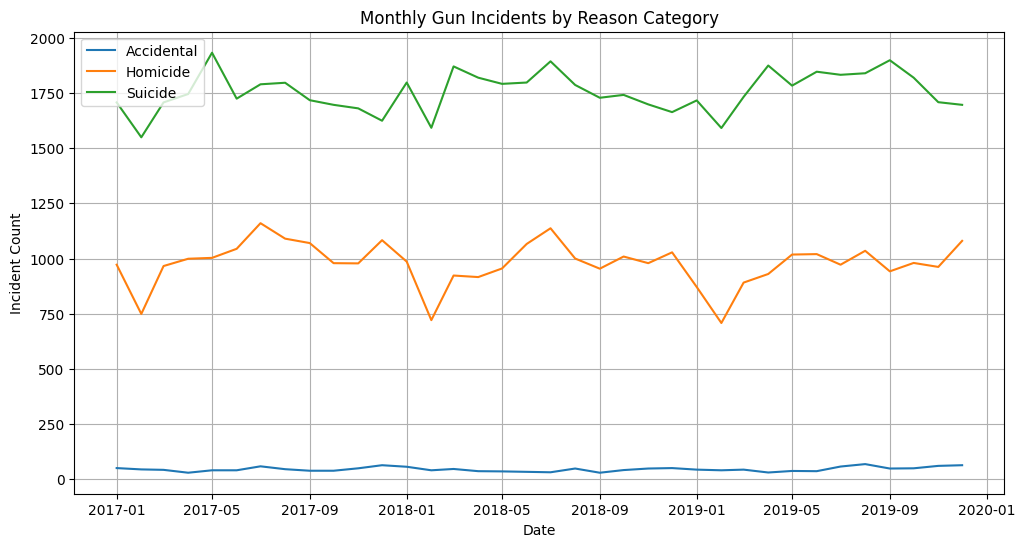

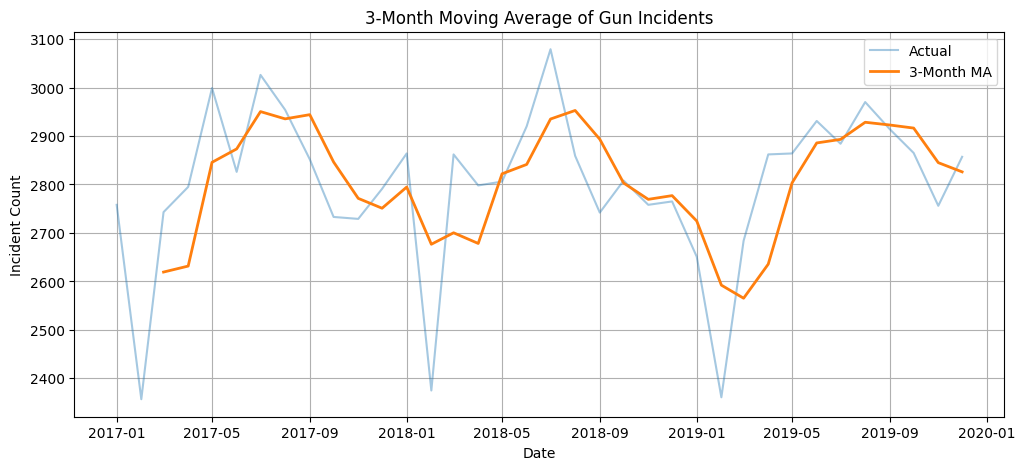

In [11]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Added for type checking


file_path = "guns_encoded (1).csv"
df = pd.read_csv(file_path)


if "S.No." in df.columns:
    df = df.drop(columns=["S.No."])


df["Date"] = pd.to_datetime(df["Date"])




monthly_total = df.groupby(["Year", "Month"]).size().reset_index(name="IncidentCount")


heatmap_data = df.groupby(["Year", "Month"]).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data.T, cmap="YlOrRd", linewidths=0.3)
plt.title("Gun Incidents Heatmap (Year × Month)")
plt.xlabel("Year")
plt.ylabel("Month")
plt.show()


monthly_total["Date2"] = pd.to_datetime(
    monthly_total["Year"].astype(str) + "-" +
    monthly_total["Month"].astype(str) + "-01"
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_total["Date2"], monthly_total["IncidentCount"], marker='o')
plt.title("Monthly Gun Incidents Over Time")
plt.xlabel("Date")
plt.ylabel("Incident Count")
plt.grid(True)
plt.show()



reason_cols = ["Reason_Accidental", "Reason_Homicide", "Reason_Suicide"]

plt.figure(figsize=(12, 6))

for col in reason_cols:
    temp = df.groupby(["Year", "Month"])[col].sum().reset_index()
    temp["Date"] = pd.to_datetime(
        temp["Year"].astype(str) + "-" +
        temp["Month"].astype(str) + "-01"
    )
    plt.plot(temp["Date"], temp[col], label=col.replace("Reason_", ""))

plt.title("Monthly Gun Incidents by Reason Category")
plt.xlabel("Date")
plt.ylabel("Incident Count")
plt.legend()
plt.grid(True)
plt.show()



monthly_total["MA3"] = monthly_total["IncidentCount"].rolling(window=3).mean()

plt.figure(figsize=(12, 5))
plt.plot(monthly_total["Date2"], monthly_total["IncidentCount"], alpha=0.4, label="Actual")
plt.plot(monthly_total["Date2"], monthly_total["MA3"], linewidth=2, label="3-Month MA")
plt.title("3-Month Moving Average of Gun Incidents")
plt.xlabel("Date")
plt.ylabel("Incident Count")
plt.grid(True)
plt.legend()
plt.show()




In [12]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report
import numpy as np


file_path = "guns_encoded (1).csv"
df = pd.read_csv(file_path)


df["HighSeverity"] = (
    (df["Reason_Homicide"] == 1) |
    (df["Reason_Suicide"] == 1)
).astype(int)

print("HighSeverity distribution:")
print(df["HighSeverity"].value_counts())


leakage_cols = [
    "Reason_Accidental",
    "Reason_Homicide",
    "Reason_Suicide",
    "Reason_Undetermined",
]


drop_cols = ["S.No.", "Date", "HighSeverity"] + leakage_cols
X = df.drop(columns=drop_cols)
y = df["HighSeverity"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("\nFeatures remaining in X (non-leakage):")
print(X.columns.tolist())


svm_model = LinearSVC(class_weight="balanced", max_iter=5000, dual='auto') # dual='auto' handles large datasets
svm_model.fit(X_train, y_train)

svm_preds = svm_model.predict(X_test)

print("\n===================== LINEAR SVM (Corrected) =====================")
print(classification_report(y_test, svm_preds))


svm_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": np.abs(svm_model.coef_[0])
}).sort_values("Importance", ascending=False)

print("\nTop Features (Linear SVM, Corrected):\n")
print(svm_importance.head(15))


coef = svm_model.coef_
if coef.ndim == 2 and coef.shape[0] == 1:
    coef = coef[0]
elif coef.ndim == 1:
    coef = coef
else:
    raise ValueError("Unexpected coef_ shape: {}".format(svm_model.coef_.shape))

weights_df = pd.DataFrame({
    "Feature": X.columns,
    "Weight": coef
})
weights_sorted = weights_df.sort_values("Weight", ascending=False).reset_index(drop=True)


print("\nTop positive weights (predict HighSeverity = 1, Corrected):")
print(weights_sorted.head(15).to_string(index=False))


print("\nTop negative weights (predict HighSeverity = 0, Corrected):")
print(weights_sorted.tail(15).sort_values("Weight").to_string(index=False))


gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)

gb_preds = gb_model.predict(X_test)

print("\n================= GRADIENT BOOSTING (Corrected) =================")
print(classification_report(y_test, gb_preds))

gb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nTop Features (Gradient Boosting, Corrected):\n")
print(gb_importance.head(15))

HighSeverity distribution:
HighSeverity
1    98351
0     2447
Name: count, dtype: int64

Features remaining in X (non-leakage):
['Year', 'Month', 'Age', 'Hispanic', 'Police involvement', 'isWeekend', 'Education_Bachelors', 'Education_High School', 'Education_Less than High School', 'Education_Some college', 'Sex_Female', 'Sex_Male', 'Race_Asian/Pacific Islander', 'Race_Black', 'Race_Hispanic', 'Race_Native American/Native Alaskan', 'Race_White', 'Place of incident_Farm', 'Place of incident_Home', 'Place of incident_Industrial/construction', 'Place of incident_Other specified', 'Place of incident_Other unspecified', 'Place of incident_Residential institution', 'Place of incident_School/instiution', 'Place of incident_Sports', 'Place of incident_Street', 'Place of incident_Trade/service area', 'day_of_week_Friday', 'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday']

===================== LINEAR SVM (